# Performance Analysis: Conway's Game of Life

This notebook benchmarks the Game of Life simulation across different grid sizes and processing strategies (single-process vs multiprocessing with varying worker counts). The goal is to determine the crossover point where multiprocessing becomes advantageous over single-process execution, and use this to set the `multiprocessing_threshold_cells` configuration default.

In [2]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add parent directory to path so we can import libs
sys.path.append(str(Path().resolve().parent))

from libs.config import BoundaryMode, SimulationConfig
from libs.parallel.dispatch import MultiprocessDispatcher, SingleProcessDispatcher

In [3]:
grid_sizes = [20, 50, 100, 200, 500, 1000]
strategies = {
    "Single Process": {"type": "single"},
    "Multiprocess (2 Workers)": {"type": "multi", "workers": 2},
    "Multiprocess (4 Workers)": {"type": "multi", "workers": 4},
    "Multiprocess (8 Workers)": {"type": "multi", "workers": 8},
}

num_generations = 20
results = []

for size in grid_sizes:
    shape = (size, size)
    print(f"Benchmarking {size}x{size} (Total Cells: {size * size})")

    # Generate random initial state
    initial_grid = np.random.choice([0, 1], size=shape, p=[0.8, 0.2]).astype(np.uint8)

    for name, strategy_config in strategies.items():
        grid_copy = initial_grid.copy()

        config = SimulationConfig(boundary_mode=BoundaryMode.TOROIDAL)

        if strategy_config["type"] == "single":
            dispatcher = SingleProcessDispatcher(boundary_mode=BoundaryMode.TOROIDAL)
        else:
            config.n_workers = strategy_config["workers"]
            dispatcher = MultiprocessDispatcher(shape=shape, config=config, initial=grid_copy)

        # Warmup
        dispatcher.step(grid_copy)

        # Benchmark
        start_ns = time.perf_counter_ns()
        for _ in range(num_generations):
            _, _, _ = dispatcher.step(grid_copy)
        end_ns = time.perf_counter_ns()

        dispatcher.shutdown()

        mean_time_ms = ((end_ns - start_ns) / 1_000_000.0) / num_generations

        results.append(
            {
                "Grid Size": size,
                "Total Cells": size * size,
                "Strategy": name,
                "Mean Time (ms)": mean_time_ms,
            }
        )
        print(f"  {name}: {mean_time_ms:.2f} ms / gen")

df = pd.DataFrame(results)

Benchmarking 20x20 (Total Cells: 400)
  Single Process: 0.30 ms / gen


  Multiprocess (2 Workers): 2.25 ms / gen
  Multiprocess (4 Workers): 2.83 ms / gen
  Multiprocess (8 Workers): 3.62 ms / gen
Benchmarking 50x50 (Total Cells: 2500)
  Single Process: 0.32 ms / gen
  Multiprocess (2 Workers): 2.44 ms / gen
  Multiprocess (4 Workers): 2.72 ms / gen
  Multiprocess (8 Workers): 3.93 ms / gen
Benchmarking 100x100 (Total Cells: 10000)
  Single Process: 0.55 ms / gen
  Multiprocess (2 Workers): 2.55 ms / gen
  Multiprocess (4 Workers): 2.96 ms / gen
  Multiprocess (8 Workers): 3.71 ms / gen
Benchmarking 200x200 (Total Cells: 40000)
  Single Process: 1.88 ms / gen
  Multiprocess (2 Workers): 3.63 ms / gen
  Multiprocess (4 Workers): 3.24 ms / gen
  Multiprocess (8 Workers): 4.17 ms / gen
Benchmarking 500x500 (Total Cells: 250000)
  Single Process: 8.65 ms / gen
  Multiprocess (2 Workers): 9.32 ms / gen
  Multiprocess (4 Workers): 6.75 ms / gen
  Multiprocess (8 Workers): 5.40 ms / gen
Benchmarking 1000x1000 (Total Cells: 1000000)
  Single Process: 27.15 ms / g

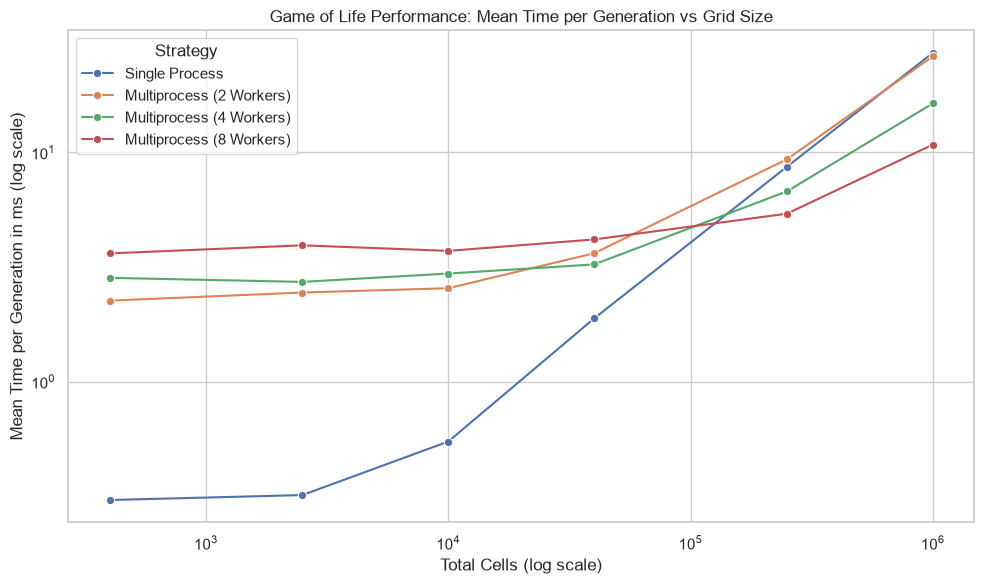

In [4]:
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Total Cells", y="Mean Time (ms)", hue="Strategy", marker="o")

plt.xscale("log")
plt.yscale("log")
plt.title("Game of Life Performance: Mean Time per Generation vs Grid Size")
plt.xlabel("Total Cells (log scale)")
plt.ylabel("Mean Time per Generation in ms (log scale)")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

## Conclusion

Based on the generated plot, we can observe the crossover point where multiprocessing overhead is overcome by parallel speedup. This value should be updated in `config.yaml` / `config.py` as the `multiprocessing_threshold_cells` value, and noted in `context.md`.